# 0. Librerias

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Limpieza básica

En este primer paso se carga el conjunto de datos obtenido a partir de la API de CoinMarketCap y se realiza una inspección preliminar de su estructura. El objetivo es verificar que la información se ha descargado correctamente y entender la forma del dataset antes de iniciar cualquier proceso de limpieza o transformación.

In [29]:
df = pd.read_csv('coinmarket_data.csv')
df.head(5)

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,...,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,12560,2010-07-13T00:00:00.000Z,"['mineable', 'pow', 'sha-256', 'store-of-value...",21000000.00000,19989081.00000,19989081.00000,...,58.41440,1465596135865.95996,NaN,2026-02-14T09:09:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-02-14 10:11:17.908928
1,1027,Ethereum,ETH,ethereum,11566,2015-08-07T00:00:00.000Z,"['pos', 'smart-contracts', 'ethereum-ecosystem...",NaN,120692467.61429,120692467.61429,...,10.53250,251535361820.57999,NaN,2026-02-14T09:09:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-02-14 10:11:17.908928
2,825,Tether USDt,USDT,tether,171208,2015-02-25T00:00:00.000Z,"['stablecoin', 'asset-backed-stablecoin', 'usd...",NaN,183816960128.68329,187964839850.99680,...,7.69410,187895100913.85999,NaN,2026-02-14T09:09:00.000Z,1027.00000,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-02-14 10:11:17.908928
3,52,XRP,XRP,xrp,1798,2013-08-04T00:00:00.000Z,"['medium-of-exchange', 'enterprise-solutions',...",100000000000.00000,60917315351.00000,99985721048.00000,...,3.69640,144912425612.82999,NaN,2026-02-14T09:09:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-02-14 10:11:17.908928
4,1839,BNB,BNB,bnb,3134,2017-07-25T00:00:00.000Z,"['marketplace', 'centralized-exchange', 'payme...",136359342.47000,136359342.47000,136359342.47000,...,3.58190,85541717698.00000,NaN,2026-02-14T09:09:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-02-14 10:11:17.908928


Dataset:

    1) 650 observaciones con 38 variables

    2) 50 criptomonedas
    
    3) Aproximadamente 13 timestamps intradía (≈ 3h a 15 min)

Esto implica que el conjunto de datos tiene una estructura de panel intrasesión, donde cada criptomoneda es observada en múltiples momentos del tiempo dentro de la misma jornada.

Para conocer la estructura completa de las variables descargadas desde la API se listan todas las columnas del DataFrame:

In [30]:
df.columns

Index(['id', 'name', 'symbol', 'slug', 'num_market_pairs', 'date_added',
       'tags', 'max_supply', 'circulating_supply', 'total_supply',
       'infinite_supply', 'minted_market_cap', 'platform', 'cmc_rank',
       'self_reported_circulating_supply', 'self_reported_market_cap',
       'tvl_ratio', 'last_updated', 'quote.USD.price', 'quote.USD.volume_24h',
       'quote.USD.volume_change_24h', 'quote.USD.percent_change_1h',
       'quote.USD.percent_change_24h', 'quote.USD.percent_change_7d',
       'quote.USD.percent_change_30d', 'quote.USD.percent_change_60d',
       'quote.USD.percent_change_90d', 'quote.USD.market_cap',
       'quote.USD.market_cap_dominance', 'quote.USD.fully_diluted_market_cap',
       'quote.USD.tvl', 'quote.USD.last_updated', 'platform.id',
       'platform.name', 'platform.symbol', 'platform.slug',
       'platform.token_address', 'timestamp'],
      dtype='object')

A continuación se realiza una primera reducción de dimensionalidad, eliminando columnas que no aportan información relevante para el análisis del comportamiento intrasesión de las criptomonedas.

In [31]:
df2 = df.drop(['date_added',
       'tags', 'platform', 'platform.id', 'platform.name', 'platform.symbol', 'platform.slug',
       'platform.token_address', 'last_updated', 'quote.USD.last_updated', 'self_reported_circulating_supply', 'self_reported_market_cap', 'tvl_ratio',
       'quote.USD.tvl', 'max_supply', 'minted_market_cap'], axis=1)

df2.head(5)

,id,name,symbol,slug,num_market_pairs,circulating_supply,total_supply,infinite_supply,cmc_rank,quote.USD.price,...,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,timestamp
0,1,Bitcoin,BTC,bitcoin,12560,19989081.00000,19989081.00000,False,1,69790.29218,...,0.37342663,4.66119,1.75617,-27.79158,-19.13826963,-27.29596,1395043803481506.00000,58.41440,1465596135865.95996,2026-02-14 10:11:17.908928
1,1027,Ethereum,ETH,ethereum,11566,120692467.61429,120692467.61429,True,2,2084.10157,...,0.51976548,6.48568,3.04826,-37.51022,-28.84438544,-35.09601,251535361820.57733,10.53250,251535361820.57999,2026-02-14 10:11:17.908928
2,825,Tether USDt,USDT,tether,171208,183816960128.68329,187964839850.99680,True,3,0.99963,...,0.00258384,0.03268,0.01686,-0.00350,-0.0183099,0.02629,183748760142.78665,7.69410,187895100913.85999,2026-02-14 10:11:17.908928
3,52,XRP,XRP,xrp,1798,60917315351.00000,99985721048.00000,False,4,1.44912,...,1.6698272,6.14788,1.90510,-31.05287,-22.85653666,-35.86945,88276759293.34933,3.69640,144912425612.82999,2026-02-14 10:11:17.908928
4,1839,BNB,BNB,bnb,3134,136359342.47000,136359342.47000,False,5,627.32568,...,0.79858334,4.36663,-1.88581,-33.39016,-26.95350155,-33.54353,85541717698.00458,3.58190,85541717698.00000,2026-02-14 10:11:17.908928


Las variables eliminadas se pueden agrupar en las siguientes categorías:

1) Metadatos descriptivos

    tags

    Información de plataforma (platform.*)

Estas variables son categóricas y descriptivas, útiles para clasificación general del activo, pero no aportan información cuantitativa relevante para el análisis intradía.

2) Variables estructurales de largo plazo

    date_added

    max_supply

    minted_market_cap

    self_reported_*

Estas métricas cambian lentamente o son prácticamente constantes en horizontes intrasesión, por lo que no aportan variabilidad útil en ventanas temporales de pocas horas.

3) Variables temporales redundantes

    last_updated

    quote.USD.last_updated

Se eliminan para evitar duplicidad con la variable timestamp, que se utilizará como referencia temporal principal del análisis.

4) Métricas DeFi no generalizables

    quote.USD.tvl

    tvl_ratio

Estas variables solo están disponibles o son relevantes para ciertos protocolos DeFi, lo que introduce inconsistencias entre activos y dificulta comparaciones homogéneas entre criptomonedas.

Antes de realizar cualquier transformación cuantitativa se inspeccionan los tipos de datos de cada variable para detectar posibles inconsistencias, especialmente en variables numéricas que han sido importadas como texto.

In [32]:
df2.dtypes

id                                      int64
name                                   object
symbol                                 object
slug                                   object
num_market_pairs                        int64
circulating_supply                    float64
total_supply                          float64
infinite_supply                          bool
cmc_rank                                int64
quote.USD.price                       float64
quote.USD.volume_24h                  float64
quote.USD.volume_change_24h           float64
quote.USD.percent_change_1h            object
quote.USD.percent_change_24h          float64
quote.USD.percent_change_7d           float64
quote.USD.percent_change_30d          float64
quote.USD.percent_change_60d           object
quote.USD.percent_change_90d          float64
quote.USD.market_cap                  float64
quote.USD.market_cap_dominance        float64
quote.USD.fully_diluted_market_cap    float64
timestamp                         

Se convierten explícitamente a tipo numérico las variables de variación porcentual que estaban almacenadas como texto.

In [33]:
cols = [
    "quote.USD.percent_change_1h",
    "quote.USD.percent_change_60d"
]

df2[cols] = df2[cols].apply(pd.to_numeric, errors="coerce")

El uso de errors="coerce" garantiza que cualquier valor no convertible se transforme en NaN, evitando errores y permitiendo un control explícito de valores faltantes en etapas posteriores.

Para facilitar la lectura y comparación de métricas financieras, se establece un formato de visualización uniforme con cinco decimales para todas las variables de tipo float.

In [34]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)

Con el objetivo de mejorar la legibilidad del dataset y simplificar la notación en fases posteriores de análisis y visualización, se renombran las columnas de variación porcentual utilizando etiquetas temporales más concisas.

Este renombrado facilita la interpretación directa de las variables temporales y mejora la claridad del código en las siguientes etapas del proyecto.

In [35]:
df2 = df2.rename(columns=
                 {'quote.USD.percent_change_1h': '1h',
                  'quote.USD.percent_change_24h': '24h',
                  'quote.USD.percent_change_7d': '7d',
                  'quote.USD.percent_change_30d': '30d',
                  'quote.USD.percent_change_60d': '60d',
                  'quote.USD.percent_change_90d': '90d'})

df2.columns

Index(['id', 'name', 'symbol', 'slug', 'num_market_pairs',
       'circulating_supply', 'total_supply', 'infinite_supply', 'cmc_rank',
       'quote.USD.price', 'quote.USD.volume_24h',
       'quote.USD.volume_change_24h', '1h', '24h', '7d', '30d', '60d', '90d',
       'quote.USD.market_cap', 'quote.USD.market_cap_dominance',
       'quote.USD.fully_diluted_market_cap', 'timestamp'],
      dtype='object')

Para poder realizar análisis intrasesión y construir métricas dependientes del tiempo, es necesario convertir la variable temporal a un formato adecuado.

In [36]:
# Conversión de timestamp a datetime UTC
df2["timestamp"] = pd.to_datetime(df2["timestamp"], utc=True, errors="coerce")

# 2. Ingeniería de variables intrasesión

En este apartado se construyen variables derivadas a partir de los datos originales con el objetivo de capturar el comportamiento intrasesión de cada criptomoneda.

Estas variables permiten:

    1) la dinámica temporal del precio

    2) medir la volatilidad intradía

    3) cuantificar la intensidad de negociación

    4) facilitar comparaciones homogéneas entre activos

La creación de estas métricas transforma el dataset original en un conjunto de características apto para análisis exploratorio avanzado y técnicas de modelado no supervisado.

Antes de calcular cualquier métrica intrasesión es imprescindible garantizar que las observaciones estén correctamente ordenadas en el tiempo para cada activo.

In [37]:
df2 = df2.sort_values(["symbol", "timestamp"])
df2 = df2.reset_index(drop=True)

### 2.1. Retorno intrasesión

La variable que se va a crear a continuación va a representar el retorno logarítmico entre dos observaciones consecutivas de precio dentro de la misma criptomoneda. Esta variable va a ser utilizada posteriormente para calcular la volatilidad, el retorno acumulado, ver cuáles son las criptomonedas más reactivas y hacer un clustering cross-sectional.

Esta métrica es ampliamente utilizada en análisis financiero debido a que:

    1) es aditiva en el tiempo

    2) permite comparar variaciones relativas entre activos

    3) es adecuada para el cálculo de volatilidad

La variable calculada se utilizará posteriormente para:

    1) estimar la volatilidad intrasesión

    2) calcular retornos acumulados

    3)identificar activos con mayor reactividad al mercado

    4) construir características para un análisis cross-sectional y técnicas de clustering

In [38]:
df2["retornos_intrasesion"] = (
    df2.groupby("symbol")["quote.USD.price"]
      .transform(lambda x: np.log(x / x.shift(1))))

df2

,id,name,symbol,slug,num_market_pairs,circulating_supply,total_supply,infinite_supply,cmc_rank,quote.USD.price,...,24h,7d,30d,60d,90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,timestamp,retornos_intrasesion
0,7278,Aave,AAVE,aave,1252,15327710.96787,16000000.00000,False,37,126.07502,...,12.41831,12.46056,-28.17944,-32.24436,-29.82570,1932441411.49303,0.08090,2017200262.24000,2026-02-14 10:11:17.908928+00:00,NaN
1,7278,Aave,AAVE,aave,1252,15327711.93078,16000000.00000,False,37,126.60549,...,13.10082,12.95196,-27.96451,-31.90730,-29.44598,1940572408.88818,0.08140,2025687766.21000,2026-02-14 10:26:18.135987+00:00,0.00420
2,7278,Aave,AAVE,aave,1252,15327711.93078,16000000.00000,False,37,127.37306,...,13.25261,14.18324,-28.22062,-31.53413,-29.16822,1952337592.55299,82.00000,2037968982.06000,2026-02-14 10:41:18.328127+00:00,0.00604
3,7278,Aave,AAVE,aave,1252,15327715.14893,16000000.00000,False,37,127.07839,...,12.87538,14.82290,-28.66078,-31.62074,-29.57181,1947821325.77348,0.08170,2033254200.61000,2026-02-14 10:56:18.506501+00:00,-0.00232
4,7278,Aave,AAVE,aave,1252,15327715.14893,16000000.00000,False,37,126.32135,...,12.17424,13.79214,-28.36719,-32.01876,-30.22235,1936217605.53490,0.08130,2021141532.68000,2026-02-14 11:11:18.751159+00:00,-0.00598
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
645,1437,Zcash,ZEC,zcash,576,16534453.54054,16534383.41554,False,21,282.26114,...,21.23879,23.35423,-36.30291,-28.16800,-60.05126,4667033655.08469,0.19570,5927483875.80000,2026-02-14 12:11:19.496759+00:00,-0.00060
646,1437,Zcash,ZEC,zcash,576,16534549.79054,16534383.41554,False,21,284.66628,...,22.71694,24.82315,-35.36787,-28.07475,-59.37564,4706828748.91715,0.19650,5977991840.08000,2026-02-14 12:26:19.675744+00:00,0.00848
647,1437,Zcash,ZEC,zcash,576,16534549.79054,16534383.41554,False,21,282.14346,...,21.69796,24.14251,-35.67368,-28.46983,-59.49275,4665115016.00111,0.19440,5925012569.26000,2026-02-14 12:41:19.975677+00:00,-0.00890
648,1437,Zcash,ZEC,zcash,576,16534549.79054,16534595.16554,False,21,280.82982,...,20.72459,24.03722,-36.06326,-28.83934,-60.02406,4643394705.87809,0.19320,5897426301.82000,2026-02-14 12:56:20.159887+00:00,-0.00467


Text(0, 0.5, 'Frecuencia')

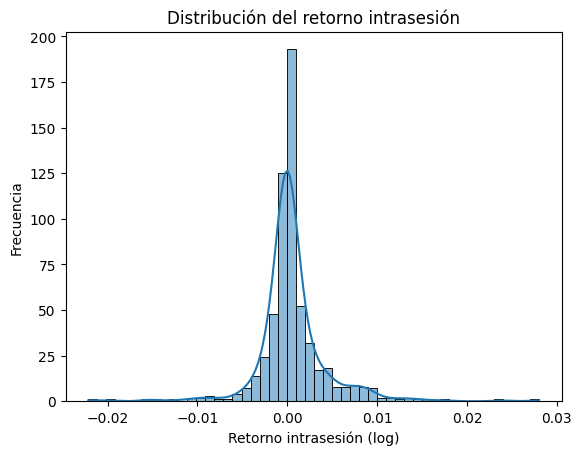

In [39]:
sns.histplot(
    df2["retornos_intrasesion"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribución del retorno intrasesión")
plt.xlabel("Retorno intrasesión (log)")
plt.ylabel("Frecuencia")

La distribución de los retornos intrasesión presenta una fuerte concentración alrededor de cero, lo que indica que la mayoría de los movimientos de precio entre observaciones consecutivas son pequeños. La forma leptocúrtica del histograma, junto con colas relativamente largas en ambos extremos, refleja la presencia de eventos de variación abrupta poco frecuentes pero significativos, un patrón característico de series financieras de alta frecuencia.

La ligera asimetría observable en las colas sugiere que los movimientos extremos no se distribuyen de manera perfectamente simétrica, lo que refuerza la conveniencia de trabajar con retornos logarítmicos y de emplear métricas agregadas como la volatilidad intrasesión para capturar el riesgo asociado a cada criptomoneda.

### 2.2 Volatilidad intrasesión

En este apartado se estima la volatilidad intrasesión de cada criptomoneda a partir de los retornos logarítmicos calculados previamente.

La volatilidad se define como la desviación estándar de los retornos intrasesión dentro de la ventana temporal observada:

In [40]:
volatilidad = (
    df2.groupby("symbol")["retornos_intrasesion"]
      .std()
      .reset_index(name="volatilidad")
)

Este cálculo proporciona una medida de la dispersión de los retornos de cada activo durante la sesión analizada, capturando su grado de inestabilidad o variabilidad de precio en el corto plazo.

### 2.3 Retorno acumulado por criptomoneda

En este apartado se calcula el retorno acumulado de la sesión para cada criptomoneda, agregando los retornos intrasesión a lo largo de la ventana temporal observada.

In [41]:
retorno_sesion = (
    df2.groupby("symbol")["retornos_intrasesion"]
      .sum()
      .reset_index(name="retorno_sesion"))

### 2.4 Intensidad de volumen

Se construye una medida de intensidad de negociación relativa como el cociente entre el volumen negociado en 24 horas y la capitalización de mercado de cada criptomoneda. Esta métrica permite comparar la actividad de negociación entre activos de distinto tamaño.

In [42]:
df2["intensidad_volumen"] = df2["quote.USD.volume_24h"] / df2["quote.USD.market_cap"]

In [43]:
volumen_sesion = (
    df2.groupby("symbol")["intensidad_volumen"]
      .mean()
      .reset_index(name="intensidad_volumen"))

### 2.5 Dataset análisis

En este apartado se integran las variables intrasesión calculadas previamente en un único dataset, donde cada fila representa una criptomoneda y cada columna una característica cuantitativa de su comportamiento durante la sesión.

In [44]:
caracteristicas = (
    retorno_sesion
      .merge(volatilidad, on="symbol")
      .merge(volumen_sesion, on="symbol"))

caracteristicas.head(10)

,symbol,retorno_sesion,volatilidad,intensidad_volumen
0,AAVE,0.01682,0.00386,0.19022
1,ADA,0.01836,0.00445,0.04340
2,ASTER,0.00942,0.00388,0.08606
3,AVAX,0.01274,0.00287,0.05228
4,BCH,-0.00525,0.00350,0.05106
5,BGB,0.01007,0.00187,0.01376
6,BNB,0.00928,0.00224,0.02006
7,BTC,0.00882,0.00286,0.01847
8,CC,-0.00067,0.00399,0.00286
9,CRO,0.00725,0.00307,0.00671


In [45]:
caracteristicas.info()
caracteristicas.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   symbol              50 non-null     object 
 1   retorno_sesion      50 non-null     float64
 2   volatilidad         50 non-null     float64
 3   intensidad_volumen  50 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.7+ KB


,retorno_sesion,volatilidad,intensidad_volumen
count,50.00000,50.00000,50.00000
mean,0.00683,0.00308,0.69356
std,0.01327,0.00238,4.47078
min,-0.05370,0.00005,0.00006
25%,0.00011,0.00164,0.02036
50%,0.00727,0.00306,0.04644
75%,0.01274,0.00397,0.08511
max,0.03751,0.01109,31.67201


'caracteristicas' es un dataset en el que cada fila es una criptomoneda y cada columna una característica agregada. Es un dataset comparativo.

Con este proceso se completa la ingeniería de variables intrasesión y se obtiene un dataset compacto y homogéneo, adecuado para análisis exploratorio y técnicas de aprendizaje no supervisado.

# 3. Ingeniería de variables avanzada

En este apartado se aplican transformaciones adicionales a las variables construidas previamente con el objetivo de mejorar su distribución estadística y facilitar el análisis multivariante posterior.

La variable de intensidad de volumen presenta una distribución altamente asimétrica, con valores extremos asociados a criptomonedas con una actividad de negociación muy elevada. Para reducir esta asimetría y estabilizar la varianza, se aplica una transformación logarítmica.

In [46]:
caracteristicas["log_intensidad_volumen"] = np.log(
    caracteristicas["intensidad_volumen"])

Se analiza la relación entre el retorno acumulado de la sesión y la volatilidad intrasesión, incorporando la intensidad de volumen como tercera dimensión visual.

Text(0, 0.5, 'Retorno de la sesión')

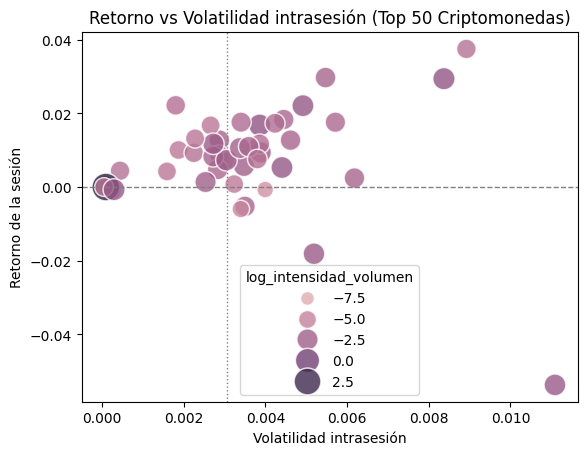

In [47]:
sns.scatterplot(
    data=caracteristicas,
    x="volatilidad",
    y="retorno_sesion",
    size="log_intensidad_volumen",
    hue="log_intensidad_volumen",
    sizes=(40, 400),
    alpha=0.8
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.axvline(
    caracteristicas["volatilidad"].median(),
    color="gray",
    linestyle=":",
    linewidth=1
)

plt.title("Retorno vs Volatilidad intrasesión (Top 50 Criptomonedas)")
plt.xlabel("Volatilidad intrasesión")
plt.ylabel("Retorno de la sesión")

El gráfico muestra una relación positiva moderada entre la volatilidad intrasesión y el retorno acumulado de la sesión para la mayoría de las criptomonedas analizadas. Los activos con volatilidad baja tienden a concentrarse en torno a retornos cercanos a cero, mientras que los mayores retornos positivos se observan en criptomonedas con niveles de volatilidad intermedia o alta.

La intensidad de volumen, representada por el tamaño y color de los puntos, sugiere que los movimientos de precio más pronunciados suelen estar asociados a una mayor actividad de negociación. No obstante, también se observan algunos activos con alta volatilidad y retornos negativos, lo que evidencia la existencia de comportamientos intrasesión heterogéneos.

Este patrón justifica la aplicación de técnicas de análisis *cross-sectional*, como el clustering, para identificar grupos de criptomonedas con perfiles similares en términos de retorno, riesgo y actividad durante la sesión analizada.


## 4. Escalado de variables

Antes de aplicar técnicas de clustering, las variables se escalan para garantizar que todas contribuyan de forma equilibrada al cálculo de distancias. El escalado es especialmente importante en algoritmos basados en distancia, como K-Means.


In [48]:
X = caracteristicas[
    ["retorno_sesion", "volatilidad", "log_intensidad_volumen"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

caracteristicas_escaladas = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=caracteristicas["symbol"])

El uso de `StandardScaler` transforma las variables para que tengan media cero y desviación estándar uno, evitando que variables con mayor escala dominen el proceso de clustering.

## 5. Selección del número de clusters

Para determinar un número adecuado de clusters se utiliza el método del codo (*elbow method*), evaluando la inercia del modelo para distintos valores de \(k\).


In [49]:
inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(caracteristicas_escaladas)
    inertia.append(kmeans.inertia_)

Text(0.5, 1.0, 'Método del codo')

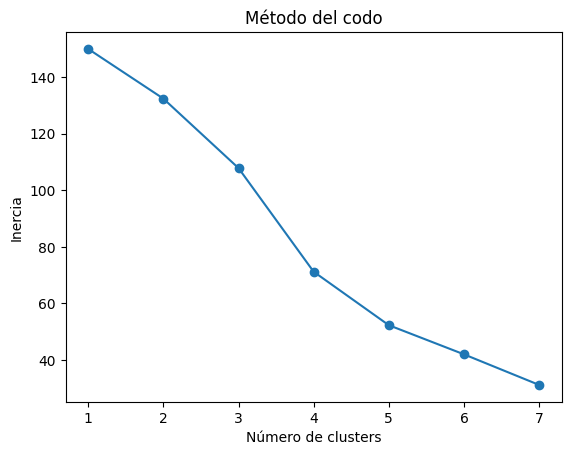

In [50]:
plt.plot(range(1, 8), inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")

El gráfico del método del codo muestra una reducción pronunciada de la inercia entre k=1 y k=4, lo que indica una mejora significativa en la compacidad de los clusters al aumentar el número de grupos en ese rango. 

A partir de k=4, la disminución de la inercia se vuelve más gradual, lo que sugiere rendimientos decrecientes en términos de mejora del modelo. Este punto de inflexión visual indica que 4 clusters representan un equilibrio adecuado entre simplicidad del modelo y capacidad de segmentación.

Por tanto, se selecciona k=4 como número óptimo de clusters para el análisis de las criptomonedas en el espacio definido por retorno, volatilidad e intensidad de volumen.


In [51]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(caracteristicas_escaladas)


In [52]:
caracteristicas_escaladas["cluster"] = clusters

caracteristicas_escaladas.groupby("cluster").mean()


,retorno_sesion,volatilidad,log_intensidad_volumen
cluster,,,
0,-0.49844,-1.14137,-3.95890
1,0.60227,0.45612,0.33759
2,-0.38946,-0.55025,-0.20050
3,-4.60916,3.40044,0.66859


La tabla muestra el valor medio de cada variable tras el escalado estándar, lo que permite comparar directamente los perfiles relativos de los distintos grupos.

Cluster 0
Presenta retornos claramente negativos, volatilidad muy inferior a la media y una intensidad de volumen extremadamente baja. Este grupo agrupa criptomonedas con escasa actividad y bajo interés del mercado, que además han tenido un comportamiento negativo durante la sesión. Se trata de activos poco reactivos, con movimientos suaves pero desfavorables.

Cluster 1
Se caracteriza por retornos positivos, volatilidad moderadamente superior a la media y una intensidad de volumen ligeramente elevada. Este perfil corresponde a criptomonedas dinámicas y líquidas, que combinan movimiento de precios con participación activa del mercado. Representa el grupo con comportamiento intrasesión más favorable.

Cluster 2
Muestra retornos negativos moderados, volatilidad por debajo de la media y una intensidad de volumen cercana al promedio. Este cluster agrupa activos con comportamiento defensivo, donde las pérdidas no son extremas y la actividad de mercado es estable. Puede interpretarse como un grupo intermedio entre activos inactivos y activos altamente dinámicos.

Cluster 3
Destaca por una volatilidad extremadamente alta y retornos muy negativos, junto con una intensidad de volumen elevada. Este grupo corresponde a criptomonedas altamente inestables, con movimientos bruscos de precio y fuerte participación del mercado, pero con un desempeño claramente desfavorable durante la sesión. Suele estar formado por pocos activos atípicos que dominan la dispersión del conjunto.

El clustering permite identificar perfiles intrasesión bien diferenciados entre las criptomonedas, separando activos líquidos y rentables, activos estables pero poco activos, y casos extremos de alta volatilidad y riesgo. Esta segmentación facilita tanto el análisis comparativo como la posterior toma de decisiones basada en comportamiento intrasesión.

Text(0.5, 1.0, 'Clustering de comportamiento intrasesión')

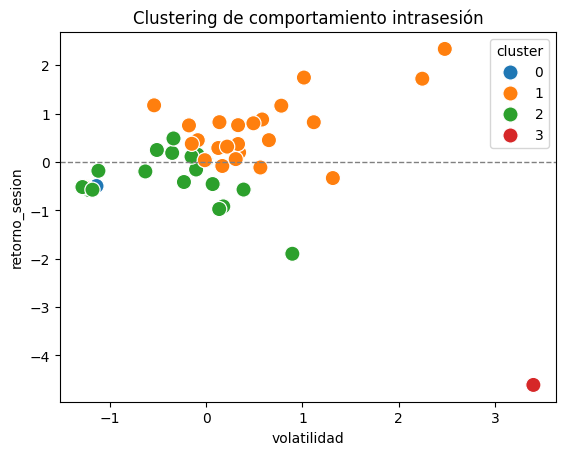

In [53]:
sns.scatterplot(
    data=caracteristicas_escaladas.reset_index(),
    x="volatilidad",
    y="retorno_sesion",
    hue="cluster",
    palette="tab10",
    s=120
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Clustering de comportamiento intrasesión")

La figura muestra la proyección bidimensional de las criptomonedas en el espacio formado por la volatilidad intrasesión (eje X) y el retorno acumulado de la sesión (eje Y), ambos en escala estandarizada. Cada punto representa una criptomoneda y el color indica el cluster asignado por el algoritmo K-means.

Se observa una separación clara entre los grupos, especialmente en el eje de retornos, lo que confirma que el clustering ha capturado diferencias estructurales en el comportamiento intrasesión:

El cluster 1 se concentra mayoritariamente en la región superior del gráfico, con retornos positivos y volatilidad moderada, lo que refuerza su interpretación como el grupo de mejor desempeño intrasesión.

El cluster 0 aparece en la zona de baja volatilidad y retornos negativos suaves, caracterizando activos poco dinámicos y con escasa capacidad de reacción.

El cluster 2 se sitúa alrededor de retornos negativos moderados y volatilidad contenida, actuando como un grupo intermedio entre activos defensivos y activos en pérdida.

El cluster 3 destaca claramente como un outlier, con volatilidad extremadamente alta y retornos muy negativos, dominando la dispersión del conjunto y justificando su separación en un cluster propio.

La línea horizontal en retorno cero facilita la identificación visual de criptomonedas con desempeño positivo frente a negativo, reforzando la lectura económica del gráfico.

Esta visualización confirma que el proceso de ingeniería de variables, escalado y clustering produce grupos coherentes y económicamente interpretables, validando el enfoque cross-sectional aplicado al comportamiento intrasesión de las criptomonedas.

## 6. Conclusiones

En este proyecto se ha analizado el comportamiento intrasesión de las 50 principales criptomonedas utilizando datos de alta frecuencia (observaciones cada 15 minutos durante una ventana aproximada de tres horas). A partir de los precios y volúmenes se han construido variables financieras clave como el retorno logarítmico intrasesión, la volatilidad y la intensidad relativa de volumen.

El análisis exploratorio muestra que los retornos intrasesión presentan una distribución centrada en cero, con colas relativamente pesadas, lo que es consistente con la alta volatilidad característica del mercado cripto incluso en ventanas temporales cortas. La mayoría de las criptomonedas experimentan movimientos pequeños, mientras que unas pocas concentran los cambios extremos.

La relación entre retorno y volatilidad no es lineal, pero se observa que las criptomonedas con mayor volatilidad intrasesión tienden a mostrar una mayor dispersión en los retornos, tanto positivos como negativos. La intensidad de volumen aporta información adicional, permitiendo diferenciar activos con movimientos relevantes respaldados por mayor actividad de mercado.

Mediante técnicas de escalado y clustering no supervisado se han identificado distintos grupos de criptomonedas con patrones intrasesión diferenciados. Estos clusters separan activos con comportamiento más estable, activos con retornos positivos moderados y activos altamente volátiles asociados a movimientos extremos, lo que evidencia la heterogeneidad del mercado incluso dentro del Top 50 por capitalización.

Finalmente, el proyecto demuestra que, incluso con una ventana temporal limitada, es posible extraer señales relevantes y construir un análisis cuantitativo coherente que combine ingeniería de variables financieras, visualización multivariable y técnicas de aprendizaje no supervisado.